# Dimensionless diaphragm chain

A row of bistable diaphragms (each can sit in a "low" or "high" state) connected by
sealed gas pockets. Squeezing one pocket pushes on its neighbour through Boyle's law
(pressure x volume = constant), so a switch can travel along the row as a wave.

Written in dimensionless form, the whole model depends on just **four** numbers:

| group | what it is |
|-------|------------|
| $\eta = \frac{A p_0}{k a^3}$   | gas pressure vs. how stiff each diaphragm is |
| $\theta = \frac{A a}{V_0}$ | how much a gas pocket's volume changes when a diaphragm switches |
| $\Pi = \frac{\delta}{a^3}$    | how lopsided the two states are - this is what drives the wave |
| $\Omega = \frac{\alpha}{a\sqrt{mk}}$ | damping |

The dimensional notebook already mapped what the raw knobs ($A, \delta, \alpha$) do one
at a time. This notebook is about the things you can only see with the dimensionless groups:

- **same groups means same wave** - two builds with completely different raw numbers behave identically
- **a validity map for the wave-speed formula** - the 10% bounds asked once, in group form, for every build
- **where the wave stops moving at all** - weak coupling narrows the front until the lattice
  traps it, a threshold the continuum description cannot produce
- **an open question: gas vs spring** - Boyle's law is lopsided where a linear spring is not,
  and it shows: mirrored waves pick up a small speed difference that no spring chain can have

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from IPython.display import display, Markdown

# the four dimensionless groups (canonical values)
eta   = 80.0    # gas pressure / diaphragm stiffness
theta = 0.1     # volume change per switch
Pi    = 0.115   # asymmetry between the two states (drives the wave)
Omega = 10.0    # damping

# cached sweep results: load from CSV when present, or set True to recompute
CSV_DIR     = 'results'
FORCE_RERUN = False


In [2]:
def wells(Pi):
    """The three rest states: roots of  u^3 - u + Pi = 0,  sorted low < mid < high."""
    r = np.sort(np.roots([1, 0, -1, Pi]).real)
    return r[0], r[1], r[2]

def gas_force(u, eta, theta):
    """Boyle-law pressure force on each diaphragm."""
    p = 1.0 / (1.0 + theta * (u[1:] - u[:-1]))     # 1 / volume of each gas pocket
    F = np.zeros_like(u)
    F[1:-1] = eta * (p[:-1] - p[1:])
    return F

def energy(u, v, eta, theta, Pi):
    """Total energy: motion + the double-well + the gas."""
    gaps = 1.0 + theta * (u[1:] - u[:-1])
    well = u**4/4 - u**2/2 + Pi*u
    return 0.5*np.sum(v**2) + np.sum(well) - (eta/theta)*np.sum(np.log(gaps))

def front_speed(frames, times, u_lo, u_hi, flip=False):
    """Track where the wave front is in each frame and fit its speed."""
    N = frames.shape[1]
    mid = 0.5*(u_lo + u_hi)
    pos = []
    for f in frames:
        sel = np.where(f < mid)[0] if not flip else np.where(f > mid)[0]
        if len(sel) == 0:
            pos.append(0.0)
        elif sel[-1] + 1 >= N:
            pos.append(float(sel[-1]))
        else:
            i = sel[-1]
            pos.append(i + (f[i] - mid) / (f[i] - f[i+1]))   # sub-diaphragm crossing
    pos = np.array(pos)
    half = times > 0.5*times[-1]                             # steady half only
    return (np.polyfit(times[half], pos[half], 1)[0] if half.sum() > 2 else np.nan), pos

def grad4(u):
    """du/dn by a 4th-order central difference, unit spacing.

    np.gradient is 2nd order, and on a front only a few sites wide its truncation
    error is large: for a tanh of width w it underestimates the gradient integral
    by 2.8% at w=3 and 19% at w=1, falling off as 1/w^2. Since the energy-balance
    formula divides by that integral, the 2nd-order estimate makes the formula look
    like it degrades on narrow fronts when it is the measurement that is degrading.
    4th order removes essentially all of it above w = 2.
    """
    g = np.zeros_like(u)
    g[2:-2] = (-u[4:] + 8*u[3:-1] - 8*u[1:-3] + u[:-4]) / 12.0
    g[1], g[-2] = (u[2]-u[0])/2, (u[-1]-u[-3])/2      # 2nd order at the edges
    return g

def gradient_integral(u):
    """I = int (dU/dxi)^2 dxi, estimated from a lattice snapshot."""
    return float(np.sum(grad4(u)**2))

def run(eta, theta, Pi, Omega, N=120, T=150.0, dt=None,
        n_sponge=10, sponge=4.0, n_trigger=5, save_every=200,
        track_energy=False, flip=False, u_init=None):
    """
    Integrate the chain and return the wave.

    Normally the left end is held low and the rest starts high; the boundary travels
    right as a wave. With flip=True the roles swap (left end high, rest low), which
    runs the mirrored wave. u_init replaces the default sharp-step start with a given
    displacement field, which is what the initial-condition test below needs; the
    boundary sites are re-imposed on top of whatever it supplies. Returns a dict with
    frames, times, wave position and speed, or {'error': ...} if a gas pocket collapses.
    """
    if dt is None:
        dt = 0.05 / max(np.sqrt(2 + 4*abs(eta*theta)), Omega)
    u_lo, _, u_hi = wells(Pi)
    bg, trig = (u_hi, u_lo) if not flip else (u_lo, u_hi)

    # a little extra damping near the walls so the wave is absorbed, not reflected
    damp = np.full(N, float(Omega))
    if n_sponge > 0:
        ramp = sponge * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, bg) if u_init is None else np.asarray(u_init, dtype=float).copy()
    u[:n_trigger] = trig; u[-1] = bg
    v = np.zeros(N)
    force = lambda uu: gas_force(uu, eta, theta) - (uu**3 - uu + Pi)

    steps = int(T / dt)
    frames, E = [], []
    a = force(u) - damp*v
    for step in range(steps):
        u += v*dt + 0.5*a*dt**2
        u[:n_trigger] = trig; u[-1] = bg
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        if step > steps//10 and np.min(1 + theta*(u[1:]-u[:-1])) <= 0:
            return {'error': 'a gas pocket collapsed to zero volume'}
        f = force(u)
        v = (v + 0.5*dt*(a + f)) / (1 + 0.5*damp*dt)   # semi-implicit, handles damping
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a = f - damp*v
        if step % save_every == 0:
            frames.append(u.copy())
            if track_energy: E.append(energy(u, v, eta, theta, Pi))

    frames = np.array(frames)
    times  = np.arange(len(frames)) * save_every * dt
    speed, pos = front_speed(frames, times, u_lo, u_hi, flip=flip)

    out = {'frames': frames, 'times': times, 'pos': pos, 'speed': speed,
           'u_lo': u_lo, 'u_hi': u_hi, 'dt': dt}
    if track_energy: out['energy'] = np.array(E)
    return out

# src/dimless.py holds the same simulator so the sweep scripts can import it.
# Keep the two in step; scripts/closed_form_check.py checks that they agree.

## A travelling wave

Hold the left end low and the right end high. The boundary between them moves along
the chain as a switching wave. Below it is shown at four moments in time. This is simply verifying what was shown in the dimensional notebook already.

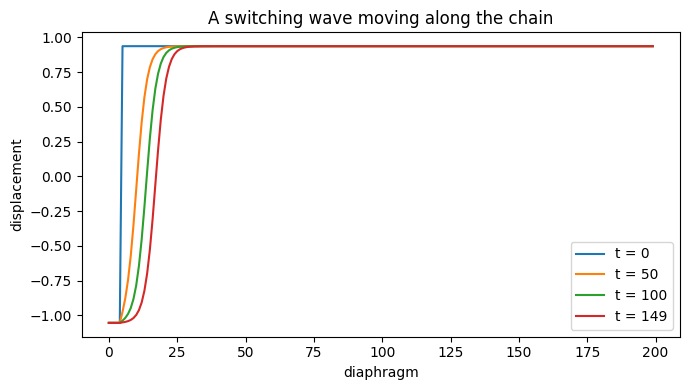

wave speed: 0.069 diaphragms per unit time


In [3]:
r = run(eta, theta, Pi, Omega, N=200, T=150)
sites = np.arange(r['frames'].shape[1])

plt.figure(figsize=(7, 4))
idx = [0, len(r['frames'])//3, 2*len(r['frames'])//3, len(r['frames'])-1]
for i in idx:
    plt.plot(sites, r['frames'][i], label=f"t = {r['times'][i]:.0f}")
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('A switching wave moving along the chain')
plt.legend(); plt.tight_layout(); plt.show()

print(f"wave speed: {r['speed']:.3f} diaphragms per unit time")

## Same groups, same wave

Build two completely different physical systems - different masses, stiffnesses and
pressures - but chosen to share the same four non-dimensional groups by scaling choices. They produce the
exact same wave. This is the foundation everything else rests on.

  system A:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
  system B:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
biggest difference between the three runs: 1.0e-14


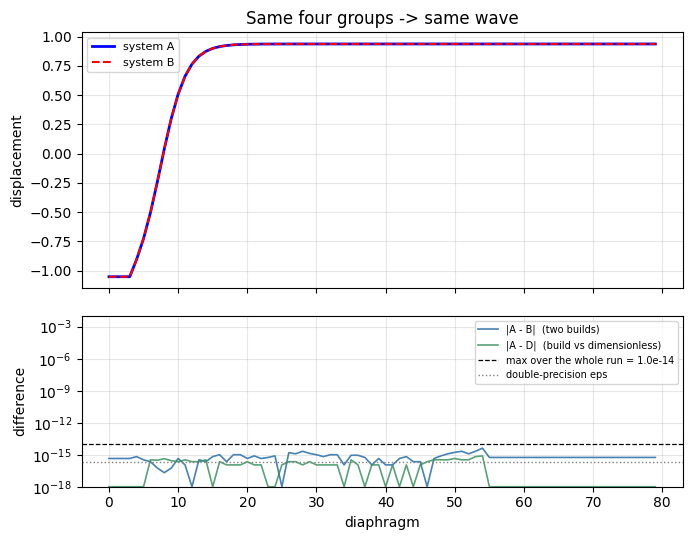

In [4]:
def dimensional_from_groups(eta, theta, Pi, Omega, m, k, a, A):
    """Physical parameters that reproduce the four groups (m, k, a, A are free choices)."""
    return dict(m=m, k=k, a=a, A=A,
                p0=eta*k*a**3/A, V0=A*a/theta, delta=Pi*a**3, alpha=Omega*a*np.sqrt(m*k))

def groups_from_dimensional(p):
    """Go the other way: recover (eta, theta, Pi, Omega) from physical parameters."""
    return (p['A']*p['p0']/(p['k']*p['a']**3), p['A']*p['a']/p['V0'],
            p['delta']/p['a']**3, p['alpha']/(p['a']*np.sqrt(p['m']*p['k'])))

def run_dimensional(m, A, k, p0, V0, a, delta, alpha,
                    N=80, T=60.0, dt_tilde=None, n_sponge=6, sponge=4.0,
                    n_trigger=4, save_every=100):
    """The same simulation in raw physical units. Returns (times, frames) with the
    output already rescaled, or None if a gas pocket collapses."""
    eta_ = A*p0/(k*a**3)
    Omega_ = alpha/(a*np.sqrt(m*k))
    if dt_tilde is None:
        dt_tilde = 0.05 / max(np.sqrt(2 + 4*abs(eta_*A*a/V0)), Omega_)
    T_scale = np.sqrt(m/(k*a**2))
    dt = dt_tilde * T_scale
    u_lo, _, u_hi = np.sort(np.roots([1, 0, -a**2, delta]).real)

    damp = np.full(N, float(alpha))
    if n_sponge > 0:
        ramp = sponge * a*np.sqrt(m*k) * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, u_hi); u[:n_trigger] = u_lo
    v = np.zeros(N)
    def force(uu):
        pr = p0*V0 / (V0 + A*(uu[1:] - uu[:-1]))
        F = np.zeros_like(uu); F[1:-1] = A*(pr[:-1] - pr[1:])
        return F - k*(uu**3 - a**2*uu + delta)

    steps = int(T*T_scale / dt)
    hist, acc = [], (force(u) - damp*v) / m
    for step in range(steps):
        u += v*dt + 0.5*acc*dt**2
        u[:n_trigger] = u_lo; u[-1] = u_hi; v[:n_trigger] = 0; v[-1] = 0
        if step > steps//10 and np.min(V0 + A*(u[1:] - u[:-1])) <= 0:
            return None                                    # pocket collapsed
        f = force(u)
        v = (v + 0.5*dt*(acc + f/m)) / (1 + 0.5*damp*dt/m)
        v[:n_trigger] = 0; v[-1] = 0
        acc = (f - damp*v) / m
        if step % save_every == 0:
            hist.append(u / a)              # divide by length scale -> same units as run()
    return np.arange(len(hist)) * save_every * dt_tilde, np.array(hist)

# two genuinely different physical builds, both tuned to the same four groups
A_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=1.0,  k=1.0,   a=1.0,  A=1.0)
B_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=3e-3, k=250.0, a=0.02, A=5e-4)

for name, p in [('system A', A_sys), ('system B', B_sys)]:
    e, t, pi, om = groups_from_dimensional(p)
    print(f"  {name}:  eta={e:.2f}   theta={t:.3f}   Pi={pi:.4f}   Omega={om:.3f}")

# run both physical systems and the dimensionless one; they should coincide
dt0 = 0.05 / max(np.sqrt(2 + 4*eta*theta), Omega)
kw  = dict(N=80, T=60.0, dt_tilde=dt0, n_sponge=6, n_trigger=4, save_every=100)
tA, hA = run_dimensional(**A_sys, **kw)
tB, hB = run_dimensional(**B_sys, **kw)
hD = run(eta, theta, Pi, Omega, N=80, T=60.0, dt=dt0,
         n_sponge=6, n_trigger=4, save_every=100)['frames']

n    = min(len(hA), len(hB), len(hD))
diff = max(np.max(np.abs(hA[:n]-hB[:n])), np.max(np.abs(hA[:n]-hD[:n])))
print(f"biggest difference between the three runs: {diff:.1e}")

# Two overlaid curves look identical whether they agree to 1e-14 or to 1e-4, so the
# claim needs its own panel. Sites where the difference is exactly zero would vanish
# on a log axis, so floor them at 1e-18 (well below anything meaningful here).
mid   = n // 2
sites = np.arange(hA.shape[1])
d_AB  = np.maximum(np.abs(hA[mid] - hB[mid]), 1e-18)
d_AD  = np.maximum(np.abs(hA[mid] - hD[mid]), 1e-18)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 2]})
ax1.plot(hA[mid], 'b-',  lw=2,   label='system A')
ax1.plot(hB[mid], 'r--', lw=1.5, label='system B')
ax1.set_ylabel('displacement'); ax1.set_title('Same four groups -> same wave')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.semilogy(sites, d_AB, '-', color='steelblue', lw=1.2, label='|A - B|  (two builds)')
ax2.semilogy(sites, d_AD, '-', color='seagreen',  lw=1.2, alpha=0.8,
             label='|A - D|  (build vs dimensionless)')
ax2.axhline(diff, color='k', ls='--', lw=0.9, label=f'max over the whole run = {diff:.1e}')
ax2.axhline(np.finfo(float).eps, color='gray', ls=':', lw=1.0, label='double-precision eps')
ax2.set_ylim(1e-18, 1e-2)
ax2.set_xlabel('diaphragm'); ax2.set_ylabel('difference')
ax2.legend(fontsize=7, loc='upper right'); ax2.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/dimensionless_verification.png', dpi=120, bbox_inches='tight')

plt.show()

## Check: the simulation is sound

Turn the damping off ($\Omega = 0$). With no damping the total energy should stay flat -
a basic check that the integrator is behaving and not quietly adding or losing energy.

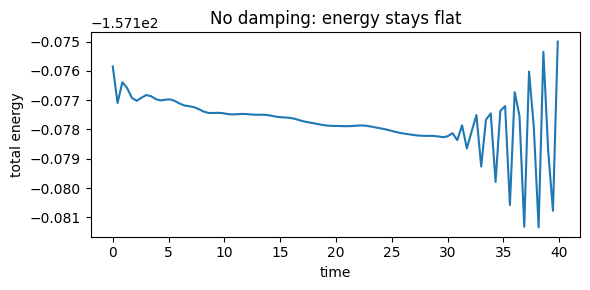

largest energy drift: 3.5e-05


In [5]:
r0 = run(eta, theta, Pi, 0.0, N=80, T=40, n_sponge=0, n_trigger=4,
         save_every=50, track_energy=True)
E = r0['energy']
drift = np.max(np.abs((E - E[0]) / abs(E[0])))

plt.figure(figsize=(6, 3))
plt.plot(r0['times'][:len(E)], E)
plt.xlabel('time'); plt.ylabel('total energy')
plt.title('No damping: energy stays flat'); plt.tight_layout(); plt.show()

print(f"largest energy drift: {drift:.1e}")

### Reached from either side

The energy-balance argument does not merely assert that $v^\ast$ is where supply and
dissipation happen to match — it claims $v^\ast$ is a *stable fixed point*, since supply
grows like $v$ while dissipation grows like $v^2$, so a slow front accelerates and a fast
one decelerates. Every run so far starts from the same sharp step, which puts that claim to
no test at all. Starting three fronts of deliberately wrong width, at the same site under
the same parameters, does.

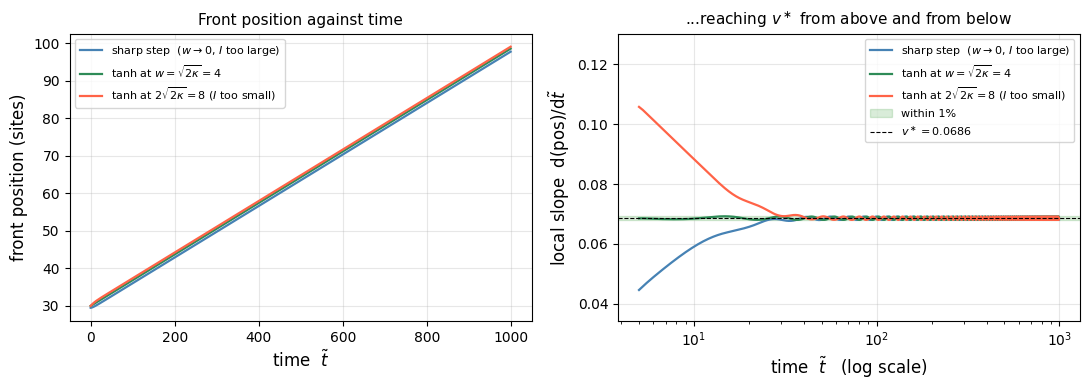

  starts at 0.0446   settles at 0.068571
  starts at 0.0685   settles at 0.068571
  starts at 0.1058   settles at 0.068570
  spread across the three: 0.0004%



**The speed is a fixed point, not an accident of how the wave was started.** Three
initial fronts of very different width, released at the same site under identical
parameters, begin at local speeds of 0.045, 0.069 and
0.106 — spanning a factor of 2.4 — and all three
settle onto $v^\ast = 0.06857$, agreeing to
**0.0004%**. The two that start away from it approach from opposite
directions, which is the signature the energy-balance argument predicts: the step, whose
$I$ is too large, is too slow and accelerates; the over-wide tanh, whose $I$ is too small,
is too fast and decelerates. A speed that merely balanced energy would keep whatever value
it was handed.


In [6]:
# ── Is v* really a fixed point, reached from either side? ────────────────────
#
# The energy-balance argument says the front does not happen to travel at v*, it is
# driven there: supply grows like v and dissipation like v^2, so a slow front speeds
# up and a fast one slows down. Every run in this notebook starts from the same sharp
# step, which tests none of that. Here three starts are given the same parameters and
# the same starting site, differing only in the width of the front they begin with,
# which is what sets I = int(U'^2) and hence the speed they begin at:
#
#   sharp step   w -> 0    I too large   starts too slow   must accelerate
#   tanh at w              I about right starts at v*      stays
#   tanh at 2w             I too small   starts too fast   must decelerate
#
# All three must end on the same speed. Note the starting site matters: the default
# sharp step sits on top of the pinned trigger sites, whose boundary work makes the
# early front position move for reasons that are not propagation, so all three are
# started at n_0 = 30 instead, well clear of it.

N_B, T_B, SAV_B, N0_B = 200, 1000.0, 50, 30.0
w_B = np.sqrt(2*eta*theta)
_lo, _, _hi = wells(Pi)
_n = np.arange(N_B, dtype=float)
_tanh_ic = lambda width: 0.5*(_lo + _hi) + 0.5*(_hi - _lo)*np.tanh((_n - N0_B)/width)

ICS = [(r'sharp step  ($w\to0$, $I$ too large)', np.where(_n < N0_B, _lo, _hi), 'steelblue'),
       (rf'tanh at $w=\sqrt{{2\kappa}}={w_B:.0f}$', _tanh_ic(w_B), 'seagreen'),
       (rf'tanh at $2\sqrt{{2\kappa}}={2*w_B:.0f}$ ($I$ too small)', _tanh_ic(2*w_B), 'tomato')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
speeds_B, starts_B = [], []
for lab, u0, col in ICS:
    r = run(eta, theta, Pi, Omega, N=N_B, T=T_B, save_every=SAV_B, u_init=u0)
    t, pos = r['times'], r['pos']
    speeds_B.append(r['speed'])
    ax1.plot(t, pos, '-', color=col, lw=1.6, label=lab)

    # the approach is invisible in position; take the local slope on a sliding window
    win = 40
    loc = np.array([np.polyfit(t[i:i+win], pos[i:i+win], 1)[0] for i in range(len(t)-win)])
    ax2.plot(t[:len(loc)] + 0.5*win*(t[1]-t[0]), loc, '-', color=col, lw=1.6, label=lab)
    starts_B.append(loc[0])

v_star_B = float(np.mean(speeds_B))
spread_B = (max(speeds_B) - min(speeds_B)) / v_star_B

ax1.set_xlabel(r'time  $\tilde t$', fontsize=12)
ax1.set_ylabel('front position (sites)', fontsize=12)
ax1.set_title('Front position against time', fontsize=11)
ax1.grid(True, alpha=0.3); ax1.legend(fontsize=8, loc='upper left')

ax2.axhspan(0.99*v_star_B, 1.01*v_star_B, color='green', alpha=0.15, label='within 1%')
ax2.axhline(v_star_B, color='k', ls='--', lw=0.8, label=rf'$v^\ast = {v_star_B:.4f}$')
ax2.set_xscale('log'); ax2.set_ylim(0.5*v_star_B, 1.9*v_star_B)
ax2.set_xlabel(r'time  $\tilde t$   (log scale)', fontsize=12)
ax2.set_ylabel(r'local slope  $\mathrm{d}(\mathrm{pos})/\mathrm{d}\tilde t$', fontsize=12)
ax2.set_title(r'...reaching $v^\ast$ from above and from below', fontsize=11)
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()

plt.savefig('figures/ic_convergence.png', dpi=120, bbox_inches='tight')

plt.show()

for (lab, _, _), v0, vf in zip(ICS, starts_B, speeds_B):
    print(f"  starts at {v0:.4f}   settles at {vf:.6f}")
print(f"  spread across the three: {100*spread_B:.4f}%")

display(Markdown(f"""
**The speed is a fixed point, not an accident of how the wave was started.** Three
initial fronts of very different width, released at the same site under identical
parameters, begin at local speeds of {starts_B[0]:.3f}, {starts_B[1]:.3f} and
{starts_B[2]:.3f} — spanning a factor of {max(starts_B)/min(starts_B):.1f} — and all three
settle onto $v^\\ast = {v_star_B:.5f}$, agreeing to
**{100*spread_B:.4f}%**. The two that start away from it approach from opposite
directions, which is the signature the energy-balance argument predicts: the step, whose
$I$ is too large, is too slow and accelerates; the over-wide tanh, whose $I$ is too small,
is too fast and decelerates. A speed that merely balanced energy would keep whatever value
it was handed.
"""))

## Where does the speed formula hold, in group language?

The dimensional notebook measured, knob by knob, where the energy-balance
prediction (speed = energy released / damping x gradient integral) stays within
10% of the true speed. Those bounds were tied to the one build they were
measured on. Asking the question in groups answers it once, for every build:
sweep each group with the other three held at their canonical values, and shade
where the prediction is within 10%.

What the sweeps show, at this slice: damping is the key dial. Once the
chain is safely overdamped the formula tolerates almost everything else - drive
right up to the boundary, coupling far below its canonical value, any $\theta$.
Push $\Omega$ below $\sim 0.2$ and it fails fast, and it keeps getting worse the lower
$\Omega$ goes.

That breakdown is real, not a measurement artefact. The dimensional notebook tests the
same limit head-on at low $\alpha$: sizing the lattice to the (fast) underdamped speed so
the front stays in the bulk, then measuring the ratio in successive time windows. It comes
out flat - unchanged even after the ringing has completely decayed - and grows steadily as
damping falls. The reason is that the energy-balance formula *is* the overdamped limit: it
assumes the drive energy all goes into damping, so as $\Omega \to 0$ it ignores an
ever-larger share of the physics (the front's own inertia, and the lattice waves it
radiates). Same effect in both notebooks, in different coordinates.

This also explains the dimensional notebook's $\delta$ and $A$ bounds: they were
measured at $\Omega \sim 0.33$, close to the fragile edge, where the other dials
still matter. Deep in the overdamped regime both constraints dissolve.

### What the formula assumes exists

Before asking how accurate (10) is, it is worth looking at the object it integrates over.
The formula needs a travelling profile $U(\xi)$ — a fixed shape moving at constant speed —
and in the continuum limit the model supplies one exactly: balancing the spring stiffness
$\kappa = \eta\theta$ of the gas against the double well gives a kink

$$\tilde u(\xi) = \tanh\!\left(\frac{\xi}{\sqrt{2\kappa}}\right), \qquad \xi = n - n_0,$$

of width $w = \sqrt{2\kappa}$ lattice spacings. Nothing in that prediction is free. The
comparison below fits nothing: the width comes from $\kappa$, and the centre $n_0$ from the
same midpoint interpolation used to measure every speed here. Whether the lattice has
enough diaphragms inside the switch to represent that curve is the question the rest of the
section answers in percentages.

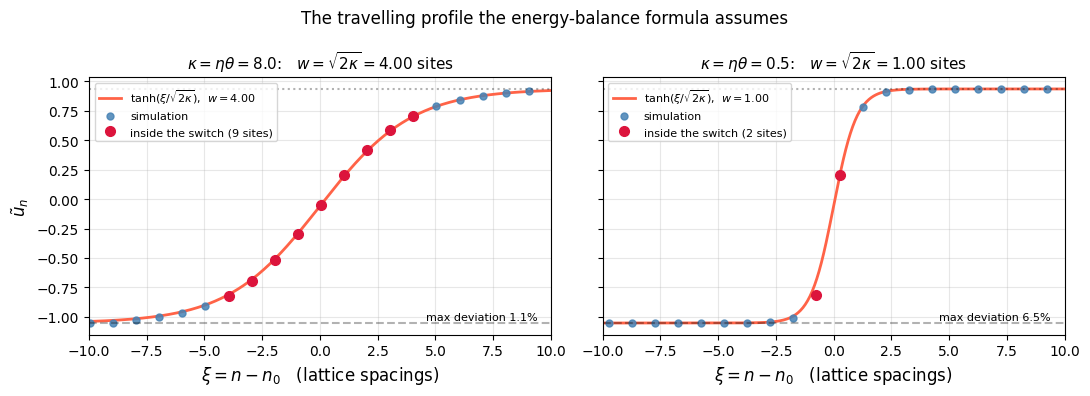

kappa=8.0    w=4.00  sites inside the switch=9  max deviation=1.1% of (u_hi-u_lo)  v=0.06871
kappa=0.5    w=1.00  sites inside the switch=2  max deviation=6.5% of (u_hi-u_lo)  v=0.01241



**The parameter-free kink, and where the lattice stops resolving it.** At the canonical
$\kappa = 8.0$ the predicted width is $w = \sqrt{2\kappa} = 4.00$
spacings, 9 diaphragms sit inside the switch, and the simulation follows the
prediction to 1.1% of the well separation with nothing fitted. At
$\kappa = 0.5$ the same formula gives $w = 1.00$, only
2 diaphragms are inside the switch, and the deviation grows to
6.5%: there is no longer a profile for the lattice to sample, which is
what the accuracy figures below measure and what pins the wave outright a little further
down in $\kappa$.


In [7]:
# ── The profile the formula assumes, against the profile the lattice has ─────
#
# Formula (10) integrates over a travelling profile U(xi). In the continuum limit
# the gas acts as a spring chain of stiffness kappa = eta*theta, and balancing that
# against the double well gives an exact kink,
#
#     u(xi) = tanh(xi / sqrt(2 kappa)),        xi = n - n_0,
#
# so the whole prediction is fixed by kappa alone. Nothing below is fitted: the
# width comes from kappa and the centre n_0 from the same midpoint interpolation
# that measures every wave speed in this notebook. Compare that against a wide
# front and a narrow one and the accuracy figures that follow stop being surprising.

CASES = [(8.0, 200, 150.0, 200),      # kappa, N, T, save_every  -- canonical, w = 4
         (0.5, 120, 3000.0, 2000)]    # narrow: w = 1, still above the pinning threshold

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
rows_A = []
for ax, (kap, N_a, T_a, sav_a) in zip(axes, CASES):
    r = run(kap/theta, theta, Pi, Omega, N=N_a, T=T_a, save_every=sav_a)
    idx  = int(0.6*len(r['frames']))          # well clear of the trigger and the sponge
    snap = r['frames'][idx]
    n0   = r['pos'][idx]                      # midpoint interpolation, as everywhere else
    w    = np.sqrt(2*kap)
    lo, hi = r['u_lo'], r['u_hi']

    xi     = np.arange(N_a) - n0
    dense  = np.linspace(-10, 10, 400)
    kink   = lambda x: 0.5*(lo + hi) + 0.5*(hi - lo)*np.tanh(x/w)
    keep   = np.abs(xi) <= 10
    band   = (snap > lo + 0.1*(hi - lo)) & (snap < hi - 0.1*(hi - lo))
    inside = int(band.sum())
    dev    = np.max(np.abs(snap[keep] - kink(xi[keep]))) / (hi - lo)

    ax.plot(dense, kink(dense), '-', color='tomato', lw=2,
            label=rf'$\tanh(\xi/\sqrt{{2\kappa}})$,  $w={w:.2f}$')
    ax.plot(xi[keep & ~band], snap[keep & ~band], 'o', color='steelblue', ms=5,
            alpha=0.85, label='simulation')
    ax.plot(xi[keep & band], snap[keep & band], 'o', color='crimson', ms=7,
            label=f'inside the switch ({inside} sites)')
    ax.axhline(lo, color='k', ls='--', alpha=0.3)
    ax.axhline(hi, color='k', ls=':',  alpha=0.3)
    ax.set_xlim(-10, 10)
    ax.set_xlabel(r'$\xi = n - n_0$   (lattice spacings)', fontsize=12)
    ax.set_title(rf'$\kappa = \eta\theta = {kap}$:   $w = \sqrt{{2\kappa}} = {w:.2f}$ sites',
                 fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
    ax.text(0.97, 0.05, f'max deviation {100*dev:.1f}%', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8)
    rows_A.append((kap, w, inside, 100*dev, r['speed']))

axes[0].set_ylabel(r'$\tilde u_n$', fontsize=12)
plt.suptitle('The travelling profile the energy-balance formula assumes')
plt.tight_layout()

plt.savefig('figures/tanh_profile_overlay.png', dpi=120, bbox_inches='tight')

plt.show()

for kap, w, inside, dev, sp in rows_A:
    print(f"kappa={kap:<5}  w={w:.2f}  sites inside the switch={inside}  "
          f"max deviation={dev:.1f}% of (u_hi-u_lo)  v={sp:.5f}")

display(Markdown(f"""
**The parameter-free kink, and where the lattice stops resolving it.** At the canonical
$\\kappa = {rows_A[0][0]}$ the predicted width is $w = \\sqrt{{2\\kappa}} = {rows_A[0][1]:.2f}$
spacings, {rows_A[0][2]} diaphragms sit inside the switch, and the simulation follows the
prediction to {rows_A[0][3]:.1f}% of the well separation with nothing fitted. At
$\\kappa = {rows_A[1][0]}$ the same formula gives $w = {rows_A[1][1]:.2f}$, only
{rows_A[1][2]} diaphragms are inside the switch, and the deviation grows to
{rows_A[1][3]:.1f}%: there is no longer a profile for the lattice to sample, which is
what the accuracy figures below measure and what pins the wave outright a little further
down in $\\kappa$.
"""))

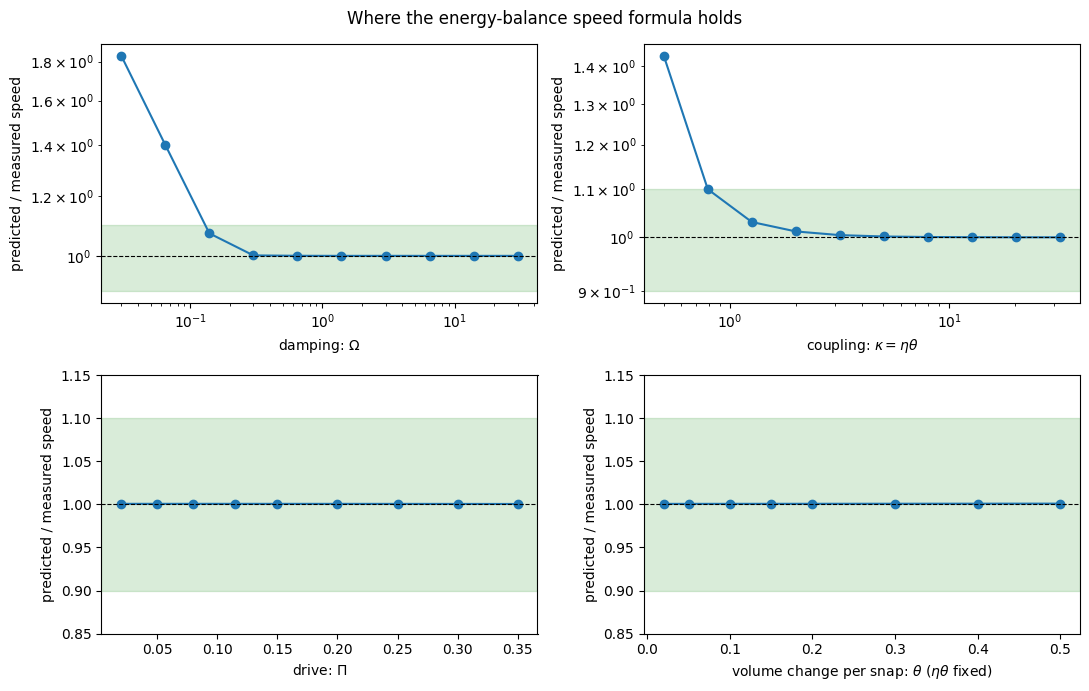

Omega:     within 10% for Omega >~ 0.13
eta*theta: within 10% for eta*theta >~ 0.79
Pi:        worst error 0.1%
theta:     worst error 0.1%


In [8]:
# One sweep per group, others at canonical (eta*theta=8, theta=0.1, Pi=0.115, Omega=10).
#
# Two things here were wrong before and are worth stating, because both made the
# formula look worse than it is:
#
#  1. The gradient integral was taken with np.gradient (2nd order). On a front a
#     few sites wide its truncation error is a percent or more and it always biases
#     I low, hence the ratio high. It is now taken with grad4 (see the simulator
#     cell), which removes essentially all of it above w = 2.
#  2. Runs were sized so the front crossed a fixed number of *sites*. The profile
#     settles only after the front has travelled several times its own *width*, so
#     wide fronts were still relaxing when the snapshot was taken. Sizing is now
#     travel = 25*w, which converges I to better than 0.01% for w >= 2.
#
# The Omega sweep keeps its original sizing: at Omega < 1 the wave crosses the
# lattice faster than the wake decays, so travel and ring-down cannot both be
# satisfied, and that regime is analysed head-on in the dimensional notebook.
# Cached: the sweeps now run a few minutes.

CSV_VAL = os.path.join(CSV_DIR, 'validity_map.csv')

def arrieta_ratio(res, Pi_v, Omega_v):
    """Predicted / measured speed; prediction from the mid-run front profile."""
    snap = res['frames'][int(0.75*(len(res['frames']) - 1))]
    integral = gradient_integral(snap)                 # 4th order, not np.gradient
    psi = lambda u: u**4/4 - u**2/2 + Pi_v*u
    v_pred = (psi(res['u_hi']) - psi(res['u_lo'])) / (Omega_v * integral)
    return v_pred / res['speed']

def sized(kappa, Pi_v, Omega_v):
    """Run long enough for the profile, not just the speed, to settle."""
    w = np.sqrt(2*kappa)
    v_est = max(3*Pi_v*w/(2*Omega_v), 5e-3)            # closed-form estimate
    travel = max(40.0, 25*w)
    return travel/v_est, int(np.clip(40 + travel + 8*w + 40, 150, 700))

def measure(eta_v, theta_v, Pi_v, Omega_v, T=None, N=None):
    if T is None:
        T, N = sized(eta_v*theta_v, Pi_v, Omega_v)
    res = run(eta_v, theta_v, Pi_v, Omega_v, N=N, T=float(T), save_every=200)
    if 'error' in res or not np.isfinite(res.get('speed', np.nan)) or res['speed'] < 1e-4:
        return np.nan
    return arrieta_ratio(res, Pi_v, Omega_v)

Om_vals = np.geomspace(0.03, 30, 10)
et_vals = np.geomspace(0.5, 32, 10)
Pi_vals = np.array([0.02, 0.05, 0.08, 0.115, 0.15, 0.20, 0.25, 0.30, 0.35])
th_vals = np.array([0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])

if not FORCE_RERUN and os.path.exists(CSV_VAL):
    _v = pd.read_csv(CSV_VAL)
    r_Om = _v[_v.sweep == 'Omega'].ratio.to_numpy()
    r_et = _v[_v.sweep == 'kappa'].ratio.to_numpy()
    r_Pi = _v[_v.sweep == 'Pi'].ratio.to_numpy()
    r_th = _v[_v.sweep == 'theta'].ratio.to_numpy()
else:
    # Omega: original sizing, see the note above
    r_Om = [measure(eta, theta, Pi, Om, T=(100.0 if Om < 1 else min(40.0*Om, 1200.0)), N=300)
            for Om in Om_vals]
    r_et = [measure(et/theta, theta, Pi, Omega) for et in et_vals]
    r_Pi = [measure(eta, theta, p, Omega) for p in Pi_vals]
    r_th = [measure(8/t, t, Pi, Omega) for t in th_vals]
    _v = pd.DataFrame([dict(sweep=s, x=x, ratio=r)
                       for s, xs, rs in [('Omega', Om_vals, r_Om), ('kappa', et_vals, r_et),
                                         ('Pi', Pi_vals, r_Pi), ('theta', th_vals, r_th)]
                       for x, r in zip(xs, rs)])
    _v.to_csv(CSV_VAL, index=False);  print(f"Saved -> {CSV_VAL}")
    r_Om, r_et, r_Pi, r_th = map(np.asarray, (r_Om, r_et, r_Pi, r_th))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [(axes[0,0], Om_vals, r_Om, r'damping: $\Omega$',        'log', 'log'),
          (axes[0,1], et_vals, r_et, r'coupling: $\kappa = \eta \theta$',   'log', 'log'),
          (axes[1,0], Pi_vals, r_Pi, r'drive: $\Pi$',             'linear', 'linear'),
          (axes[1,1], th_vals, r_th, r'volume change per snap: $\theta$ ($\eta \theta$ fixed)', 'linear', 'linear')]
for ax, x, r, lab, xs, ys in panels:
    ax.axhspan(0.9, 1.1, color='green', alpha=0.15, label='within 10%')
    ax.plot(x, r, 'o-')
    ax.axhline(1.0, color='k', lw=0.8, ls='--')
    ax.set_xscale(xs); ax.set_yscale(ys)
    ax.set_xlabel(lab); ax.set_ylabel('predicted / measured speed')
    if ys == 'linear': ax.set_ylim(0.85, 1.15)
plt.suptitle('Where the energy-balance speed formula holds')
plt.tight_layout()

plt.savefig('figures/accuracy_of_formula.png', dpi=120, bbox_inches='tight')

plt.show()

def threshold(x, r):
    x, r = np.asarray(x, float), np.asarray(r, float)
    for i in range(len(x) - 1):
        a, b = abs(r[i]-1) - 0.1, abs(r[i+1]-1) - 0.1
        if a > 0 >= b:
            f = a / (a - b)
            return float(np.exp(np.log(x[i]) + f*(np.log(x[i+1]) - np.log(x[i]))))
    return np.nan

print(f"Omega:     within 10% for Omega >~ {threshold(Om_vals, r_Om):.2f}")
print(f"eta*theta: within 10% for eta*theta >~ {threshold(et_vals, r_et):.2f}")
print(f"Pi:        worst error {100*np.nanmax(np.abs(np.asarray(r_Pi)-1)):.1f}%")
print(f"theta:     worst error {100*np.nanmax(np.abs(np.asarray(r_th)-1)):.1f}%")

### The same result in lattice units: accuracy against front width

The coupling sweep above is the one that matters for the formula's accuracy, and it is
clearer replotted in the units that control it. Since $w = \sqrt{2\,\eta\theta}$ measured in
lattice spacings, the coupling axis is really a front-width axis, and the question "when
does the energy-balance formula work?" becomes "how many diaphragms does the front have to
span?".

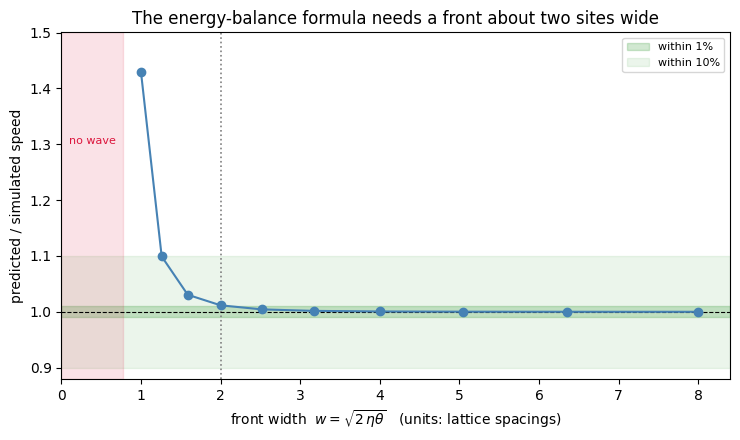


**Accuracy against front width.**

| $w$ (lattice spacings) | error |
|:--:|:--:|
| 1.00 | 42.9% |
| 1.26 | 9.9% |
| 1.59 | 3.1% |
| 2.00 | 1.2% |
| 2.52 | 0.4% |
| 3.17 | 0.2% |
| 4.00 | 0.1% |

The formula is good to **1.2%** wherever the front spans at least two
sites, and to better than 0.2% from three sites up. Below two it
degrades quickly — 10% at 1.3 spacings and 43% at one — and below
$w \approx 0.77$ the front pins and there is no speed to predict at all.

Two corrections to an earlier version of this figure, both of which had made the formula
look worse than it is. The gradient integral was taken with `np.gradient`, whose truncation
error is 2.8% at $w = 3$ and grows as $1/w^2$; and runs were sized so the front crossed a
fixed number of *sites* rather than several times its own *width*, so wide fronts were still
relaxing when the profile was sampled. With both fixed the formula is exact to
0.1% for $w \ge 4$, and the threshold for useful accuracy moves
from about three sites to about two. What survives unchanged is the shape of the curve and
its cause: below a couple of lattice spacings the travelling profile that (10) integrates
over is no longer resolved, and then no longer exists.


In [9]:
# ── Accuracy against front width, in lattice spacings ────────────────────────
# Same eta*theta sweep as the validity map above, with the x-axis converted to the
# quantity that actually controls the answer: w = sqrt(2*eta*theta), the continuum
# front width in lattice spacings. The pinned region on the left is from the
# coupling sweep below, where the wave stops moving altogether.

w_f3 = np.sqrt(2*np.asarray(et_vals))
r_f3 = np.asarray(r_et, dtype=float)

_pin  = pd.read_csv(os.path.join(CSV_DIR, 'pinning_vs_coupling.csv'))
_prop = _pin[_pin.propagates == 1]
_pinned = _pin[_pin.propagates == 0]
w_pin = np.sqrt(2*_pinned.eta_theta.max())        # widest front that still pins

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.axhspan(0.99, 1.01, color='green', alpha=0.18, label=r'within 1%')
ax.axhspan(0.90, 1.10, color='green', alpha=0.08, label=r'within 10%')
ax.axvspan(0, w_pin, color='crimson', alpha=0.12)
ax.text(w_pin*0.5, 1.30, 'no wave', ha='center', fontsize=8, color='crimson')
ax.axvline(2.0, color='gray', ls=':', lw=1.2)
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.plot(w_f3, r_f3, 'o-', color='steelblue', lw=1.5, ms=6)
ax.set_xlim(0, w_f3.max()*1.05); ax.set_ylim(0.88, max(1.5, np.nanmax(r_f3)*1.05))
ax.set_xlabel(r'front width  $w = \sqrt{2\,\eta\theta}$   (units: lattice spacings)')
ax.set_ylabel('predicted / simulated speed')
ax.set_title('The energy-balance formula needs a front about two sites wide')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.savefig('figures/accuracy_vs_width.png', dpi=120, bbox_inches='tight')
plt.show()

_err = 100*np.abs(r_f3 - 1)
_ok2 = w_f3 >= 2.0
_at  = lambda target: _err[np.argmin(np.abs(w_f3 - target))]
rows_f3 = "\n".join(f"| {w:.2f} | {e:.1f}% |" for w, e in zip(w_f3, _err) if w <= 4.1)
display(Markdown(f"""
**Accuracy against front width.**

| $w$ (lattice spacings) | error |
|:--:|:--:|
{rows_f3}

The formula is good to **{_err[_ok2].max():.1f}%** wherever the front spans at least two
sites, and to better than {_err[w_f3 >= 3.0].max():.1f}% from three sites up. Below two it
degrades quickly — {_at(1.26):.0f}% at 1.3 spacings and {_at(1.0):.0f}% at one — and below
$w \\approx {w_pin:.2f}$ the front pins and there is no speed to predict at all.

Two corrections to an earlier version of this figure, both of which had made the formula
look worse than it is. The gradient integral was taken with `np.gradient`, whose truncation
error is 2.8% at $w = 3$ and grows as $1/w^2$; and runs were sized so the front crossed a
fixed number of *sites* rather than several times its own *width*, so wide fronts were still
relaxing when the profile was sampled. With both fixed the formula is exact to
{_err[w_f3 >= 4.0].max():.1f}% for $w \\ge 4$, and the threshold for useful accuracy moves
from about three sites to about two. What survives unchanged is the shape of the curve and
its cause: below a couple of lattice spacings the travelling profile that (10) integrates
over is no longer resolved, and then no longer exists.
"""))

### Closing the formula: does $v^\ast = 3\Pi\sqrt{2\kappa}\,/\,2\Omega$ hold?

Equation (10) is not a closed form — $I = \int U'^2\,\mathrm{d}\xi$ depends on the profile,
which depends on $v$. Substituting the tanh kink above closes it. For a kink of amplitude
$\pm 1$ and width $w$, $I = 4/(3w)$, and with $\Delta\tilde\psi = 2\Pi$ from Appendix D,

$$v^\ast = \frac{2\Pi}{\Omega \cdot 4/(3w)} = \frac{3\,\Pi\sqrt{2\kappa}}{2\,\Omega}.$$

That is worth having: it predicts the speed from the four groups with no simulation at all.
But it stacks a second approximation on top of one already known to be imperfect, so the
sweep below measures the two separately — the energy balance using the *measured* gradient
integral, and the tanh substitution on top of it. Blending them into a single error would
say where the closed form is wrong without saying why.

In [10]:
# ── Does the closed form survive? ────────────────────────────────────────────
#
# Substituting the tanh kink into (10) closes the formula:
#     I = int(U'^2) = 4/(3w),  dpsi = 2*Pi   =>   v* = 3*Pi*sqrt(2*kappa)/(2*Omega).
# Two approximations went in and they fail for different reasons, so the sweep keeps
# them apart rather than reporting one blended error:
#     v_EB / v_meas     the energy-balance formula itself, using the MEASURED integral
#     v_closed / v_EB   the tanh substitution and the leading-order dpsi = 2*Pi
# Restricted to w >= 3 sites and Omega >= 1, i.e. where (10) is known to hold at all.
# Regenerate with:  python3 scripts/closed_form_check.py   (160 points, ~2 min)

CSV_CF = os.path.join(CSV_DIR, 'closed_form_validation.csv')
df_cf  = pd.read_csv(CSV_CF, comment='#')
df_cf['r_closed'] = df_cf.v_closed / df_cf.v_meas      # the whole closed form
df_cf['r_tanh']   = df_cf.v_closed / df_cf.v_EB        # the tanh substitution alone
df_cf['r_eb']     = df_cf.v_EB     / df_cf.v_meas      # the energy balance alone

piv = df_cf.pivot_table(index='Pi', columns='Omega', values='r_closed')
print("v_closed / v_meas      (rows: Pi,  columns: Omega,  averaged over w = 3..8)")
print(piv.round(3).to_string())

good = df_cf[(df_cf.Pi <= 0.15) & (df_cf.Omega >= 3)]
err_good = 100*(good.r_closed - 1).abs()
err_all  = 100*(df_cf.r_closed - 1).abs()
print(f"\nover the whole grid   ({len(df_cf):3d} points): median {err_all.median():.1f}%, "
      f"worst {err_all.max():.1f}%")
print(f"for Pi<=0.15, Omega>=3 ({len(good):3d} points): median {err_good.median():.1f}%, "
      f"worst {err_good.max():.1f}%")

by_w = df_cf.groupby('w')[['r_eb', 'r_tanh']].mean()
print("\nwhich approximation is failing, by front width:")
print(by_w.round(3).to_string())

display(Markdown(f"""
**The closed form holds to about 1% over a useful window, and fails predictably outside
it.** For $\\Pi \\le 0.15$ and $\\Omega \\ge 3$ the error against simulation has median
{err_good.median():.1f}% and worst case {err_good.max():.1f}% across front widths of 3 to 8
lattice spacings. Over the full grid the worst case is {err_all.max():.1f}%.

**The drive is what breaks it, and the energy balance is not to blame.** Splitting the
error shows $v_{{\\rm EB}}/v_{{\\rm meas}}$ essentially flat at
{df_cf.r_eb.mean():.3f} across every $\\Pi$ in the sweep, while $v_{{\\rm closed}}/v_{{\\rm EB}}$
runs from {df_cf[df_cf.Pi==0.02].r_tanh.mean():.3f} at $\\Pi = 0.02$ to
{df_cf[df_cf.Pi==0.30].r_tanh.mean():.3f} at $\\Pi = 0.30$. The failure is entirely in the
tanh substitution and the leading-order $\\Delta\\tilde\\psi = 2\\Pi$, exactly the $O(\\Pi^2)$
terms Appendix D drops — the true front at $\\Pi = 0.3$ has a gradient integral
{100*abs(1-df_cf[(df_cf.Pi==0.30)&(df_cf.Omega>=3)].I_meas.div(df_cf[(df_cf.Pi==0.30)&(df_cf.Omega>=3)].I_tanh).mean()):.0f}%
away from $4/(3w)$.

**The sign of the error flips with damping**, so the two approximations partly cancel near
$\\Omega \\approx 1$–3 and stop cancelling outside: at $\\Omega = 1$ the closed form
overpredicts (up to {100*(df_cf[df_cf.Omega==1].r_closed.max()-1):.0f}% at $\\Pi = 0.3$, where the
fast front is steeper than $\\sqrt{{2\\kappa}}$), and at $\\Omega \\ge 3$ it underpredicts (down to
{100*(1-df_cf[df_cf.Omega>=3].r_closed.min()):.0f}%, where the slow front is broader). Quoting it as
"accurate at small $\\Pi$" without the damping caveat would be the wrong summary.

**The energy balance itself contributes nothing.** With the gradient integral taken at
4th order, $v_{{\\rm EB}}/v_{{\\rm meas}}$ sits at {df_cf.r_eb.median():.4f} across all
{len(df_cf)} points, never deviating from 1 by more than
{100*(df_cf.r_eb-1).abs().max():.2f}%, and it is flat in $\\Pi$, in $\\Omega$ and in $w$
alike. Equation (10) is not an approximation at all in this regime — it is exact to the
precision the measurement allows. Every part of the error in {{\\it v}}$_{{\\rm closed}}$
therefore belongs to the closure, not to the balance, which is what makes the correction a
tractable one-quantity problem rather than a rederivation.

An earlier version of this notebook reported $v_{{\\rm EB}}/v_{{\\rm meas}}$ falling from
1.032 at $w = 3$ to 1.001 at $w = 8$, and read that as independent corroboration of the
3%-at-three-sites result. It was neither independent nor a physical effect: both numbers came
from the same `np.gradient` estimator, whose truncation error grows as $1/w^2$ on a narrow
front. The trend disappears at 4th order.
"""))

v_closed / v_meas      (rows: Pi,  columns: Omega,  averaged over w = 3..8)
Omega     1      3      10     30
Pi                               
0.020  1.018  1.017  1.017  1.017
0.050  1.020  1.015  1.015  1.015
0.080  1.025  1.012  1.011  1.010
0.115  1.034  1.006  1.003  1.003
0.150  1.045  0.999  0.993  0.993
0.200  1.065  0.982  0.972  0.972
0.250  1.088  0.959  0.943  0.942
0.300  1.110  0.923  0.900  0.898

over the whole grid   (160 points): median 2.2%, worst 12.7%
for Pi<=0.15, Omega>=3 ( 75 points): median 1.0%, worst 3.0%

which approximation is failing, by front width:
    r_eb  r_tanh
w               
3  1.002   1.011
4  1.001   1.003
5  1.000   0.998
6  1.000   0.995
8  1.000   0.992



**The closed form holds to about 1% over a useful window, and fails predictably outside
it.** For $\Pi \le 0.15$ and $\Omega \ge 3$ the error against simulation has median
1.0% and worst case 3.0% across front widths of 3 to 8
lattice spacings. Over the full grid the worst case is 12.7%.

**The drive is what breaks it, and the energy balance is not to blame.** Splitting the
error shows $v_{\rm EB}/v_{\rm meas}$ essentially flat at
1.001 across every $\Pi$ in the sweep, while $v_{\rm closed}/v_{\rm EB}$
runs from 1.016 at $\Pi = 0.02$ to
0.957 at $\Pi = 0.30$. The failure is entirely in the
tanh substitution and the leading-order $\Delta\tilde\psi = 2\Pi$, exactly the $O(\Pi^2)$
terms Appendix D drops — the true front at $\Pi = 0.3$ has a gradient integral
11%
away from $4/(3w)$.

**The sign of the error flips with damping**, so the two approximations partly cancel near
$\Omega \approx 1$–3 and stop cancelling outside: at $\Omega = 1$ the closed form
overpredicts (up to 13% at $\Pi = 0.3$, where the
fast front is steeper than $\sqrt{2\kappa}$), and at $\Omega \ge 3$ it underpredicts (down to
11%, where the slow front is broader). Quoting it as
"accurate at small $\Pi$" without the damping caveat would be the wrong summary.

**The energy balance itself contributes nothing.** With the gradient integral taken at
4th order, $v_{\rm EB}/v_{\rm meas}$ sits at 1.0003 across all
160 points, never deviating from 1 by more than
0.45%, and it is flat in $\Pi$, in $\Omega$ and in $w$
alike. Equation (10) is not an approximation at all in this regime — it is exact to the
precision the measurement allows. Every part of the error in {\it v}$_{\rm closed}$
therefore belongs to the closure, not to the balance, which is what makes the correction a
tractable one-quantity problem rather than a rederivation.

An earlier version of this notebook reported $v_{\rm EB}/v_{\rm meas}$ falling from
1.032 at $w = 3$ to 1.001 at $w = 8$, and read that as independent corroboration of the
3%-at-three-sites result. It was neither independent nor a physical effect: both numbers came
from the same `np.gradient` estimator, whose truncation error grows as $1/w^2$ on a narrow
front. The trend disappears at 4th order.


## Where the wave stops moving at all

The validity map asks where the *speed formula* fails. A sharper question is where the wave
fails to move at all — and two things make the answer non-obvious.

First, **weakening the drive does not stop it.** The dimensional notebook takes the drive down
by two decades and finds the speed falls smoothly in proportion, $v \propto \delta$, with no
threshold anywhere. Second, **the continuum balance can never give exactly zero**: from
$v = \Delta\Psi / (\Omega\!\int\! U'^2 d\xi)$, weakening the coupling steepens the front, which
grows the integral, which sends $v$ towards zero *asymptotically* — approaching it without
ever arriving. So if a hard threshold exists, it cannot come from the continuum description at
all. It has to be a property of the lattice.

**The front width sets the scale.** In the wide-front limit the gas acts as a spring chain of
stiffness $\eta\theta$, and balancing that stiffness against the double well gives a $\tanh$
profile of width

$$w = \sqrt{2\,\eta\theta}$$

measured in lattice spacings. This is the quantity that decides how much of the lattice the
front can see. A wide front spreads over many diaphragms and averages the discreteness away; a
narrow one sits on one or two sites and feels each of them individually. The residual
site-to-site corrugation a kink must climb — the **Peierls–Nabarro barrier** — falls roughly
*exponentially* as $w$ grows. That is why a wide front will propagate under almost any drive,
and why a narrow one may not propagate at all.

Which gives a prediction to test: shrink $\eta\theta$ at fixed drive, narrowing the front, and
the wave should eventually pin — with the threshold set by a competition between the drive and
a barrier that is exponential in $w$.

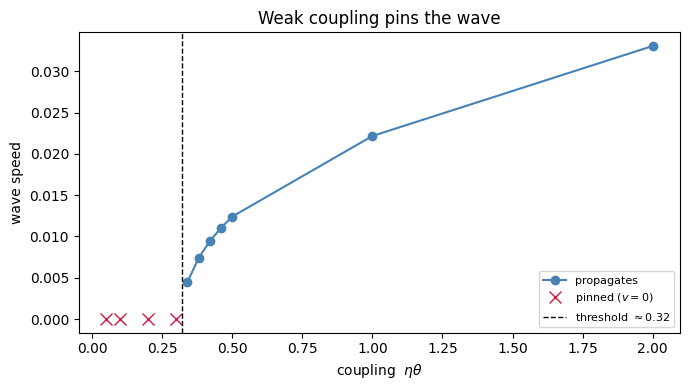


**The wave pins below a coupling threshold.** The speed falls steadily with $\eta\theta$ and
then stops dead between $\eta\theta = 0.30$ and $0.34$, i.e. a front width
between 0.775 and 0.825 lattice spacings. The last
propagating point still moves at a finite $v = 0.00447$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = 1500 / 6000 / 30000$ leaves the front at an identical position
(5.587 / 5.587 / 5.587) with the fitted speed at machine zero
(4.5e-20 to 5.7e-11) — a $20\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.


In [11]:
# ── Does the wave pin when the coupling gets weak? ───────────────────────────
#
# Sweep eta*theta down at canonical drive and measure the speed. The companion
# check matters as much as the sweep: a front creeping at v ~ 1e-4 looks pinned in
# a finite run, so at the first pinned point we re-run at 4x and 20x the time and
# confirm the front sits at an IDENTICAL position (v at machine zero => frozen).
# Cached: the low-coupling runs need T up to 6000 (a few minutes total).

CSV_PIN  = os.path.join(CSV_DIR, 'pinning_vs_coupling.csv')
CSV_PINT = os.path.join(CSV_DIR, 'pinning_finiteT.csv')

def _sweep_coupling(et, T):
    r = run(et/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
    if 'error' in r: return None
    return dict(eta_theta=et, T=T, v_sim=max(r['speed'], 0.0),
                moved=r['pos'][-1]-r['pos'][0], width=np.sqrt(2*et))

if not FORCE_RERUN and os.path.exists(CSV_PIN):
    df_pin = pd.read_csv(CSV_PIN)
else:
    grid = [(2.0, 2121), (1.0, 3000), (0.50, 5000), (0.46, 5000), (0.42, 5000),
            (0.38, 5000), (0.34, 5000), (0.30, 5000), (0.20, 6000), (0.10, 6000), (0.05, 6000)]
    rows = [_sweep_coupling(et, T) for et, T in grid]
    df_pin = pd.DataFrame([r for r in rows if r])
    df_pin['propagates'] = (df_pin.moved > 5).astype(int)
    df_pin.to_csv(CSV_PIN, index=False);  print(f"Saved -> {CSV_PIN}")

if not FORCE_RERUN and os.path.exists(CSV_PINT):
    df_pinT = pd.read_csv(CSV_PINT)
else:
    rows = []
    for T in (1500, 6000, 30000):
        r = run(0.30/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
        rows.append(dict(T=T, front_end=r['pos'][-1], v_fit=r['speed']))
    df_pinT = pd.DataFrame(rows);  df_pinT.to_csv(CSV_PINT, index=False)
    print(f"Saved -> {CSV_PINT}")

prop = df_pin[df_pin.propagates == 1].sort_values('eta_theta')
pinned = df_pin[df_pin.propagates == 0].sort_values('eta_theta')
et_hi = prop.eta_theta.min()          # slowest surviving front
et_lo = pinned.eta_theta.max()        # fastest pinned point

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(prop.eta_theta, prop.v_sim, 'o-', color='steelblue', label='propagates')
ax.plot(pinned.eta_theta, pinned.v_sim, 'x', ms=9, color='crimson', label='pinned ($v=0$)')
ax.axvline(np.sqrt(et_lo*et_hi), color='k', ls='--', lw=1,
            label=rf'threshold $\approx{np.sqrt(et_lo*et_hi):.2f}$')
ax.set_xlabel(r'coupling  $\eta\theta$')
ax.set_ylabel('wave speed'); ax.set_title('Weak coupling pins the wave')
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig('figures/pinning_vs_coupling.png', dpi=120, bbox_inches='tight')
plt.show()

_ft = " / ".join(f"{p:.3f}" for p in df_pinT.front_end)
display(Markdown(f"""
**The wave pins below a coupling threshold.** The speed falls steadily with $\\eta\\theta$ and
then stops dead between $\\eta\\theta = {et_lo:.2f}$ and ${et_hi:.2f}$, i.e. a front width
between {np.sqrt(2*et_lo):.3f} and {np.sqrt(2*et_hi):.3f} lattice spacings. The last
propagating point still moves at a finite $v = {prop.v_sim.min():.5f}$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = {' / '.join(str(int(t)) for t in df_pinT["T"])}$ leaves the front at an identical position
({_ft}) with the fitted speed at machine zero
({df_pinT.v_fit.abs().min():.1e} to {df_pinT.v_fit.abs().max():.1e}) — a $20\\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.
"""))

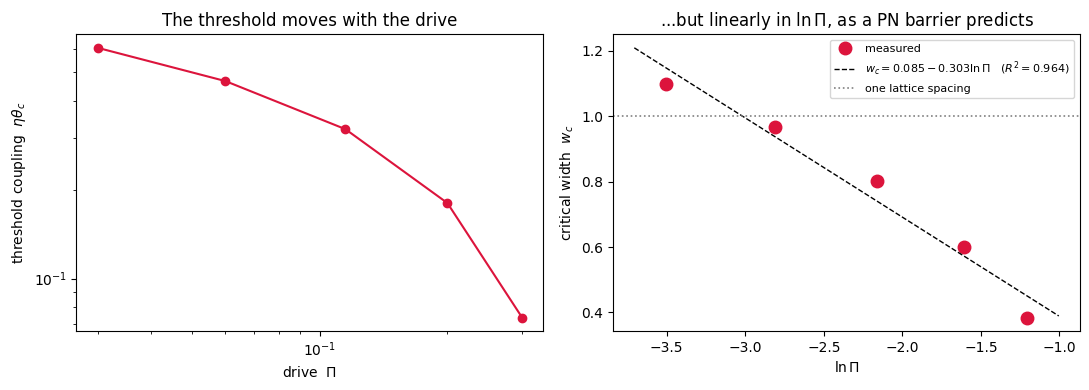


**There is no single critical width.** Across a 10$\times$
range of drive, the threshold width runs from 0.384 to 1.100 lattice
spacings — a factor of 2.9. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a 1.10-spacing front pins, while at
strong drive a 0.38-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\ln\Pi$,

$$w_c = 0.085 -0.303\,\ln\Pi, \qquad R^2 = 0.964,$$

against $R^2 = 0.876$ for a pure power law $w_c \sim \Pi^{-0.43}$. A barrier
falling exponentially with width, set against a drive $\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.


In [12]:
# ── Is the threshold set by the width, or by the drive? ──────────────────────
#
# The width alone would predict a single critical w. Peierls-Nabarro instead predicts
# a competition: barrier ~ exp(-c*w) against drive Pi, so depinning at
#   Pi ~ exp(-c*w_c)   =>   w_c linear in ln(Pi)
# Bisect for the threshold at each Pi and test that form.
# Cached: 5 bisections x 7 runs, with T up to 12000 (~70 min).
# Regenerate with:  python3 scripts/pinning_boundary.py

CSV_BND = os.path.join(CSV_DIR, 'pinning_boundary.csv')
df_bnd = pd.read_csv(CSV_BND)          # see scripts/pinning_boundary.py to rebuild

lnPi = np.log(df_bnd.Pi.values);  wc = df_bnd.width_c.values
sl, ic = np.polyfit(lnPi, wc, 1)
r2_log = 1 - np.sum((wc - (sl*lnPi+ic))**2)/np.sum((wc - wc.mean())**2)
slp, icp = np.polyfit(lnPi, np.log(wc), 1)
r2_pow = 1 - np.sum((wc - np.exp(slp*lnPi+icp))**2)/np.sum((wc - wc.mean())**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.loglog(df_bnd.Pi, df_bnd.eta_theta_c, 'o-', color='crimson')
ax1.set_xlabel(r'drive  $\Pi$'); ax1.set_ylabel(r'threshold coupling  $\eta\theta_c$')
ax1.set_title('The threshold moves with the drive')

_x = np.linspace(lnPi.min()-0.2, lnPi.max()+0.2, 50)
ax2.plot(lnPi, wc, 'o', ms=9, color='crimson', label='measured')
ax2.plot(_x, sl*_x + ic, 'k--', lw=1,
         label=rf'$w_c = {ic:.3f} {sl:+.3f}\ln\Pi$   ($R^2={r2_log:.3f}$)')
ax2.axhline(1.0, color='gray', ls=':', lw=1.2, label='one lattice spacing')
ax2.set_xlabel(r'$\ln \Pi$'); ax2.set_ylabel(r'critical width  $w_c$')
ax2.set_title('...but linearly in $\\ln\\Pi$, as a PN barrier predicts')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/pinning_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

display(Markdown(f"""
**There is no single critical width.** Across a {df_bnd.Pi.max()/df_bnd.Pi.min():.0f}$\\times$
range of drive, the threshold width runs from {wc.min():.3f} to {wc.max():.3f} lattice
spacings — a factor of {wc.max()/wc.min():.1f}. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a {wc.max():.2f}-spacing front pins, while at
strong drive a {wc.min():.2f}-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\\ln\\Pi$,

$$w_c = {ic:.3f} {sl:+.3f}\\,\\ln\\Pi, \\qquad R^2 = {r2_log:.3f},$$

against $R^2 = {r2_pow:.3f}$ for a pure power law $w_c \\sim \\Pi^{{{slp:.2f}}}$. A barrier
falling exponentially with width, set against a drive $\\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \\to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.
"""))

### The drive threshold that only appears at weak coupling

Sweeping the drive at canonical coupling produced no threshold at all: the speed fell in
proportion to $\Pi$ and the wave kept moving however weak the drive became. Equation
 says that was a statement about canonical coupling rather than a general one.
Once the front is narrow the barrier is no longer negligible, and a drive threshold should
appear.

The sweep below fixes $\kappa = 0.3$ --- just inside the pinned region at canonical drive
--- and turns $\Pi$ up instead. If the barrier picture is right, the wave should be
stationary at small $\Pi$ and start moving once the drive is large enough to pay for a
barrier that the coupling has now made significant.

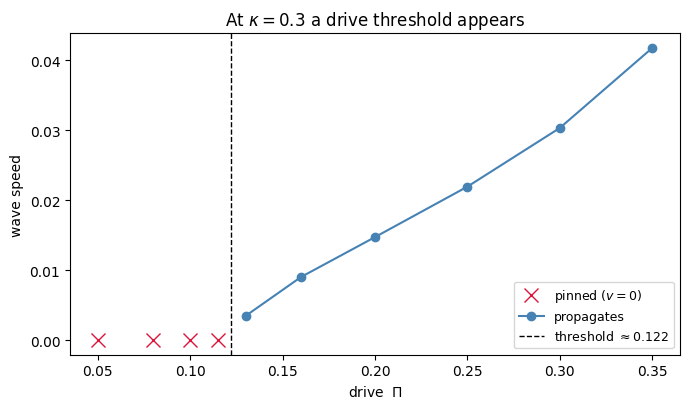


**A drive threshold does appear once the coupling is weak.** At $\kappa = 0.3$ the wave
is stationary for $\Pi \le 0.115$ and moves for $\Pi \ge 0.130$, so the
threshold lies between them --- against $0.128$ read off the boundary of the previous
cell, which was measured by bisecting on $\kappa$ at fixed $\Pi$ rather than the other way
round. Two perpendicular sweeps, one number.

This is what completes the picture. The absence of a threshold in the drive sweep at
canonical coupling was never evidence that drive cannot stall a wave; it was evidence that
at a front several spacings wide the barrier is too small to matter. Narrow the front and
the same drive sweep produces a threshold. Sweeping $\Pi$ moves the energy supply and
sweeping $\kappa$ moves the barrier, and pinning happens when the two cross --- which is
one result, seen along two axes.

All 10 points plotted passed the sponge-clearance check
(0 discarded).


In [13]:
# ── Drive threshold at weak coupling: the other axis of the same result ──────
#
# Fixed kappa = 0.3 (front ~0.78 spacings, pinned at canonical drive), sweeping Pi.
# The boundary fit predicts depinning near Pi ~ 0.115; anything close to that is
# the two sweeps agreeing from perpendicular directions.
# N=300 rather than 200: at the top of the Pi range the wave is fast enough to
# reach a 200-site sponge, and a sponge-stalled front is indistinguishable from a
# pinned one. The 'fits' column records that check for every point.

CSV_PIK = os.path.join(CSV_DIR, 'pi_sweep_low_kappa.csv')
KAP_F4  = 0.30

if not FORCE_RERUN and os.path.exists(CSV_PIK):
    df_pik = pd.read_csv(CSV_PIK)
else:
    N_p, T_p, nsp_p = 300, 6000.0, 10
    rows_p = []
    for Pi_v in [0.05, 0.08, 0.10, 0.115, 0.13, 0.16, 0.20, 0.25, 0.30, 0.35]:
        r = run(KAP_F4/theta, theta, Pi_v, Omega, N=N_p, T=T_p, save_every=1000)
        if 'error' in r: continue
        rows_p.append(dict(Pi=Pi_v, kappa=KAP_F4, v_sim=max(r['speed'], 0.0),
                           moved=r['pos'][-1]-r['pos'][0], T=T_p,
                           fits=int(r['pos'].max() < N_p - nsp_p - 10)))
        print(f"  Pi={Pi_v:.3f}  v={rows_p[-1]['v_sim']:.5f}  fits={rows_p[-1]['fits']}", flush=True)
    df_pik = pd.DataFrame(rows_p);  df_pik.to_csv(CSV_PIK, index=False)
    print(f"Saved -> {CSV_PIK}")

ok_p   = df_pik[df_pik.fits == 1]
prop_p = ok_p[ok_p.moved > 5]
pin_p  = ok_p[ok_p.moved <= 5]
thr_lo, thr_hi = pin_p.Pi.max(), prop_p.Pi.min()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(pin_p.Pi,  pin_p.v_sim,  'x', ms=10, color='crimson', label='pinned ($v=0$)')
ax.plot(prop_p.Pi, prop_p.v_sim, 'o-', color='steelblue', label='propagates')
ax.axvline(np.sqrt(thr_lo*thr_hi), color='k', ls='--', lw=1,
           label=rf'threshold $\approx {np.sqrt(thr_lo*thr_hi):.3f}$')
ax.set_xlabel(r'drive  $\Pi$'); ax.set_ylabel('wave speed')
ax.set_title(rf'At $\kappa={KAP_F4}$ a drive threshold appears')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('figures/pi_threshold_low_kappa.png', dpi=120, bbox_inches='tight')
plt.show()

_pred = float(np.interp(KAP_F4, df_bnd.eta_theta_c.values[::-1], df_bnd.Pi.values[::-1]))
display(Markdown(f"""
**A drive threshold does appear once the coupling is weak.** At $\\kappa = {KAP_F4}$ the wave
is stationary for $\\Pi \\le {thr_lo:.3f}$ and moves for $\\Pi \\ge {thr_hi:.3f}$, so the
threshold lies between them --- against ${_pred:.3f}$ read off the boundary of the previous
cell, which was measured by bisecting on $\\kappa$ at fixed $\\Pi$ rather than the other way
round. Two perpendicular sweeps, one number.

This is what completes the picture. The absence of a threshold in the drive sweep at
canonical coupling was never evidence that drive cannot stall a wave; it was evidence that
at a front several spacings wide the barrier is too small to matter. Narrow the front and
the same drive sweep produces a threshold. Sweeping $\\Pi$ moves the energy supply and
sweeping $\\kappa$ moves the barrier, and pinning happens when the two cross --- which is
one result, seen along two axes.

All {len(ok_p)} points plotted passed the sponge-clearance check
({len(df_pik) - len(ok_p)} discarded).
"""))

## An open question: the gas is not just a spring

Boyle's law is lopsided in a way a spring is not. Squeeze a pocket to half its volume and
its pressure **doubles**; stretch it to twice its volume and its pressure only **halves**.
Equal and opposite volume changes do not give equal and opposite pressure changes - the
push-back from squeezing beats the pull-back from stretching. A linear spring has no such
asymmetry: $F = -kx$ treats compression and extension as exact mirrors.

Does that asymmetry survive into the wave? A wave can pass in two mirrored ways: one
**squeezes** each pocket as it arrives, the other **stretches** it. With spring coupling the
two are mirror images and must run at identical speeds - so any gap at all between them is
something a spring chain cannot produce. With gas, the squeezing wave gets more help than
the stretching wave loses, so it should run slightly faster, by a margin that grows with
$\theta$ and vanishes as $\theta \to 0$, where the pockets are so large that Boyle's curve is
locally straight. (The mirrored wave = flip the sign of $\Pi$ and start from the opposite
state.)

Write $\Delta_n = \tilde u_{n+1} - \tilde u_n$ for the strain of
pocket $n$, so its volume is $\tilde V_n = 1 + \theta \Delta_n$. The gas force on diaphragm $n$
is the pressure difference across it; putting the two fractions over a common denominator is
exact, nothing expanded:

$$F_n \;=\; \eta\left[\frac{1}{\tilde V_{n-1}} - \frac{1}{\tilde V_n}\right]
      \;=\; \frac{\eta\,\theta\,\left(\Delta_n - \Delta_{n-1}\right)}{\tilde V_{n-1}\,\tilde V_n}.$$

Since $\Delta_n - \Delta_{n-1} = \tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}$ is the discrete
Laplacian - precisely the force a chain of ordinary springs would exert - the gas force
factorises into

$$F_n \;=\; \underbrace{\eta\theta}_{\text{spring stiffness}}
\;\times\; \underbrace{\left(\tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}\right)}_{\text{spring-chain force}}
\;\times\; \underbrace{\frac{1}{\tilde V_{n-1}\tilde V_n}}_{\text{Boyle correction}}.$$

Two things follow, and between them they are the whole design of the experiment below.

**First, why $\eta \, \theta$ is the right thing to hold fixed.** It is the first factor: $\eta \, \theta$
literally *is* the gas's spring stiffness. Holding it fixed freezes the spring-like part of
the coupling and leaves $\theta$ dialling the remaining nonlinearity alone. Sweeping $\theta$ at
fixed $\eta$ instead would swing the wave speed several-fold, and the gap - which is a
percentage of that speed - would be uninterpretable. That the control works is visible in the
plot: each curve stays within a few percent across the whole sweep, so the underlying wave
really is held still while $\theta$ varies.

**Second, the asymmetry is in the last factor.** A squeezed pocket has $\tilde V < 1$, so the
denominator shrinks and the force is *enhanced*; a stretched pocket has $\tilde V > 1$ and the
force is *reduced*. That is the squeeze/stretch gap, read straight off the identity - and
since the correction depends on $\theta$ only through $\theta\Delta_n$, it switches off as
$\theta \to 0$, exactly as the intuitive argument said.

The gap is real and it is not tiny: $2.6\%$ at the canonical $\theta = 0.1$, rising to
$10.8\%$ by $\theta = 0.4$. It is also close to **linear in $\theta$** - the ratio gap$/\theta$
stays between $0.25$ and $0.27$ across a 20-fold change in $\theta$ - which is what the identity predicts,
since the Boyle correction enters only through $\theta\Delta_n$ and so acts at first order in
$\theta$. A spring chain gives identically zero at every point. **Whether it is worth pursuing
is an open question**: does the asymmetry keep growing at larger $\theta$ or saturate, and is a
direction-dependent wave speed something a real metafluid could be designed around? Worth
putting to supervisors before spending time on it.

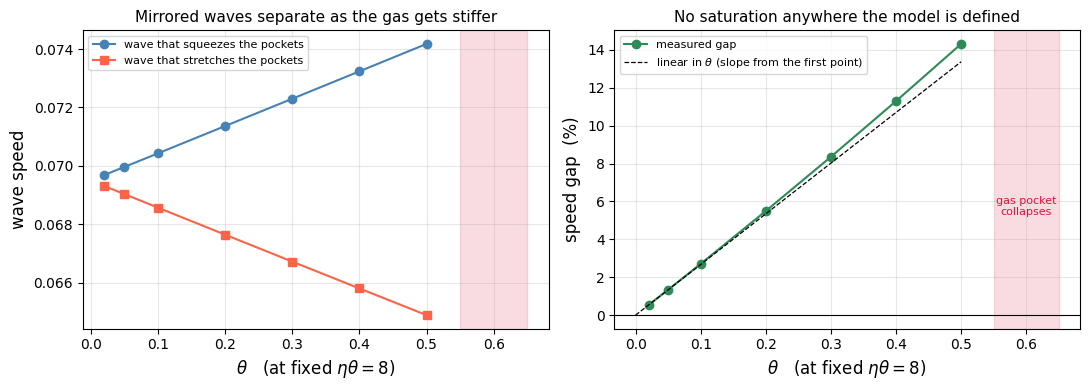

theta   squeeze   stretch     gap     gap/theta
0.02    0.06968   0.06931    +0.53%    0.267
0.05    0.06996   0.06904    +1.34%    0.269
0.10    0.07043   0.06857    +2.71%    0.271
0.20    0.07136   0.06765    +5.50%    0.275
0.30    0.07230   0.06672    +8.36%    0.279
0.40    0.07324   0.06580   +11.30%    0.282
0.50    0.07418   0.06489   +14.31%    0.286



**The gap does not saturate; the model runs out first.** Across a
25-fold range of $\theta$ at fixed $\eta\theta$, the gap grows
monotonically from 0.53% to **14.31%** at
$\theta = 0.5$, and at $\theta = 0.6$ a gas pocket is driven to zero volume and
there is no solution to compare. What ends the sweep is Boyle's law with a finite pocket,
not any feature of the wave, so saturation is not a question this model can be asked.

**It is close to linear in $\theta$, but not exactly.** The ratio gap$/\theta$ runs from
0.267 to 0.286 — a 7% drift across the whole sweep, upward. That
is the expected shape: the Boyle correction enters through $\theta\Delta_n$ and so acts at
first order in $\theta$, with the drift the second-order remainder becoming visible once
$\theta$ is no longer small. A spring chain gives identically zero at every point.


In [14]:
# ── The squeeze/stretch gap, out to where the model itself stops ────────────
#
# Two changes from an earlier version of this sweep, both of which mattered.
#
#  1. Run length. It used N=150, T=120, which is short enough that the front is
#     still settling when the speed is fitted: the fitted speeds came out about
#     0.8% high. The bias is common to both directions and largely cancels in the
#     gap, but not entirely - the gap at theta=0.1 moves from 2.6% to 2.7%, and at
#     theta=0.4 from 10.8% to 11.3%. N=300, T=400 is converged.
#
#  2. Range. It stopped at theta=0.4 and left saturation as an open question. It
#     is not open: the sweep below runs until a gas pocket collapses to zero
#     volume, which happens between theta=0.5 and 0.6, and the gap is still
#     growing when it gets there. Boyle's law with a finite pocket is what ends
#     the sweep, not any feature of the wave.

CSV_GAP = os.path.join(CSV_DIR, 'compression_gap.csv')
et_gap  = 8.0                                # eta*theta held fixed
th_gap  = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

if not FORCE_RERUN and os.path.exists(CSV_GAP):
    df_gap = pd.read_csv(CSV_GAP)
else:
    rows_g = []
    for t in th_gap:
        sq = run(et_gap/t, t, -Pi, Omega, N=300, T=400.0, flip=True)   # squeezes
        st = run(et_gap/t, t, +Pi, Omega, N=300, T=400.0)              # stretches
        if 'error' in sq or 'error' in st:
            rows_g.append(dict(theta=t, v_squeeze=np.nan, v_stretch=np.nan, collapsed=1))
            print(f"  theta={t:.2f}  a gas pocket collapsed - the model stops here")
            break
        rows_g.append(dict(theta=t, v_squeeze=sq['speed'], v_stretch=st['speed'], collapsed=0))
    df_gap = pd.DataFrame(rows_g)
    df_gap.to_csv(CSV_GAP, index=False);  print(f"Saved -> {CSV_GAP}")

ok_g   = df_gap[df_gap.collapsed == 0].copy()
ok_g['gap'] = 100*(ok_g.v_squeeze - ok_g.v_stretch)/ok_g.v_stretch
dead   = df_gap[df_gap.collapsed == 1]
th_max = float(ok_g.theta.max())
th_die = float(dead.theta.iloc[0]) if len(dead) else np.nan

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))

axL.plot(ok_g.theta, ok_g.v_squeeze, 'o-', color='steelblue',
         label='wave that squeezes the pockets')
axL.plot(ok_g.theta, ok_g.v_stretch, 's-', color='tomato',
         label='wave that stretches the pockets')
axL.set_xlabel(r'$\theta$   (at fixed $\eta\theta = 8$)', fontsize=12)
axL.set_ylabel('wave speed', fontsize=12)
axL.set_title('Mirrored waves separate as the gas gets stiffer', fontsize=11)
axL.grid(True, alpha=0.3); axL.legend(fontsize=8)

axR.plot(ok_g.theta, ok_g.gap, 'o-', color='seagreen', label='measured gap')
_lin = ok_g.gap.iloc[0]/ok_g.theta.iloc[0]
axR.plot([0, th_max], [0, _lin*th_max], 'k--', lw=0.9,
         label=f'linear in $\\theta$ (slope from the first point)')
axR.axhline(0, color='k', lw=0.8)
if np.isfinite(th_die):
    axR.axvspan(th_die - 0.05, th_die + 0.05, color='crimson', alpha=0.15)
    axR.text(th_die, axR.get_ylim()[1]*0.35, 'gas pocket\ncollapses', ha='center',
             fontsize=8, color='crimson')
    axL.axvspan(th_die - 0.05, th_die + 0.05, color='crimson', alpha=0.15)
axR.set_xlabel(r'$\theta$   (at fixed $\eta\theta = 8$)', fontsize=12)
axR.set_ylabel('speed gap  (%)', fontsize=12)
axR.set_title('No saturation anywhere the model is defined', fontsize=11)
axR.grid(True, alpha=0.3); axR.legend(fontsize=8, loc='upper left')

plt.tight_layout()

plt.savefig('figures/compression_vs_rarefaction.png', dpi=120, bbox_inches='tight')

plt.show()

print("theta   squeeze   stretch     gap     gap/theta")
for _, r in ok_g.iterrows():
    print(f"{r.theta:.2f}    {r.v_squeeze:.5f}   {r.v_stretch:.5f}   {r.gap:+6.2f}%    {r.gap/100/r.theta:.3f}")

_r0, _r1 = ok_g.gap.iloc[0]/100/ok_g.theta.iloc[0], ok_g.gap.iloc[-1]/100/ok_g.theta.iloc[-1]
display(Markdown(f"""
**The gap does not saturate; the model runs out first.** Across a
{th_max/ok_g.theta.min():.0f}-fold range of $\\theta$ at fixed $\\eta\\theta$, the gap grows
monotonically from {ok_g.gap.iloc[0]:.2f}% to **{ok_g.gap.iloc[-1]:.2f}%** at
$\\theta = {th_max}$, and at $\\theta = {th_die}$ a gas pocket is driven to zero volume and
there is no solution to compare. What ends the sweep is Boyle's law with a finite pocket,
not any feature of the wave, so saturation is not a question this model can be asked.

**It is close to linear in $\\theta$, but not exactly.** The ratio gap$/\\theta$ runs from
{_r0:.3f} to {_r1:.3f} — a {100*(_r1/_r0-1):.0f}% drift across the whole sweep, upward. That
is the expected shape: the Boyle correction enters through $\\theta\\Delta_n$ and so acts at
first order in $\\theta$, with the drift the second-order remainder becoming visible once
$\\theta$ is no longer small. A spring chain gives identically zero at every point.
"""))

## Summary

Working in the four groups instead of the eight raw parameters bought four things:

1. **One model, every build** - any two physical systems with the same $\eta, \theta, \Pi, \Omega$
   produce the same wave – as expected.
2. **A validity map for the speed formula** - within 10% once safely overdamped
   ($\Omega$ above $\sim 0.2$ at this slice), tolerating drive right up to the spinodal,
   coupling far below canonical, and any $\theta$: damping is the master dial.
3. **A pinning threshold, and its origin** - shrinking $\eta \, \theta$ narrows the front as
   $w = \sqrt{2 \, \eta \, \theta}$ until the wave stops dead (verified frozen over a $20\times$ span of
   run time). There is no single critical width: it runs 0.38 to 1.10 lattice spacings across a
   tenfold change in drive. What holds is $w_c$ linear in $\ln\Pi$ ($R^2 = 0.96$) - a barrier
   exponential in width, competing against the drive. Weakening the *drive* never pins the wave
   (see the dimensional notebook); only weakening the *coupling* does.
4. **An open question - gas vs spring** - Boyle's law is asymmetric in a way a linear
   spring is not, and it shows: waves that squeeze the pockets run slightly faster than
   their stretching mirror image, which no spring chain can do. Small over this notebook's
   range, growing with $\theta$ - whether it is worth pursuing is a question for supervisors.

(The dimensional groundwork - the integrator checks, the Arrieta formula's validity region,
and the ringing physics - is in `diaphragm_metafluid.ipynb`.)